In [1]:
import numpy as np
import scipy

import matplotlib.pyplot as plt

import mne
from mne.preprocessing import ICA

from asrpy import ASR
from mne_icalabel import label_components

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, ShuffleSplit
from mne.decoding import Vectorizer, FilterEstimator, CSP
from mne.decoding import UnsupervisedSpatialFilter

from mne_realtime import MockRtClient, RtEpochs

import pyautogui
import pyxdf
import pylsl
from mnelab.io import read_raw

In [2]:
path = "/Users/alkalisk/Downloads/Recording/"
fname = path + "1113/sub-oreo_ses-1113_task-Default_run-001_eeg.xdf"
streams, header = pyxdf.load_xdf(fname)
for i in streams:
    if i['info']['name'][0] == 'obci_eeg1':
        idx = i['info']['stream_id']
    print(i['info']['name'][0])
    print('stream_id: ' + str(i['info']['stream_id']))
    print('---')
print('idx is ' + str(idx))

Stream 4: Calculated effective sampling rate 101.8037 Hz is different from specified rate 125.0000 Hz.


MotorImag-Markers
stream_id: 2
---
obci_eeg1
stream_id: 1
---
obci_eeg2
stream_id: 3
---
aux
stream_id: 4
---
idx is 1


In [3]:
raw_ori = read_raw(fname, stream_ids=[idx], fs_new=125)

Stream 4: Calculated effective sampling rate 101.8037 Hz is different from specified rate 125.0000 Hz.


Creating RawArray with float64 data, n_channels=16, n_times=168751
    Range : 0 ... 168750 =      0.000 ...  1350.000 secs
Ready.


In [35]:

'''eeg_stream = None
msg_stream = None

streams, header = pyxdf.load_xdf(fname)
# detect the EEG stream
states_list_eeg = pyxdf.match_streaminfos(pyxdf.resolve_streams(fname),
                                          [{"type": "EEG"}])
for states_stream_id in states_list_eeg:
    for stream in streams:
        if stream["info"]["stream_id"] == states_stream_id:
            eeg_stream = stream
            print('Found eeg stream {}'.format(states_stream_id))
            break
assert eeg_stream is not None, 'EEG stream not found'

# detect the message stream
states_list_ids = pyxdf.match_streaminfos(pyxdf.resolve_streams(fname),
                                          [{"type": "Markers"}])
for states_stream_id in states_list_ids:
    for stream in streams:
        if stream["info"]["stream_id"] == states_stream_id:
            msg_stream = stream
            print('Found message stream {}'.format(states_stream_id))
            break
assert eeg_stream is not None, 'lsl message stream not found in xdf file'
first_samp = eeg_stream["time_stamps"][0]
print('first time stamp correction {}'.format(first_samp))
onsets = msg_stream["time_stamps"] - first_samp
descriptions = [item for sub in msg_stream["time_series"] for item in sub]
raw.annotations.append(onsets, [0] * len(onsets), descriptions)
'''


'eeg_stream = None\nmsg_stream = None\n\nstreams, header = pyxdf.load_xdf(fname)\n# detect the EEG stream\nstates_list_eeg = pyxdf.match_streaminfos(pyxdf.resolve_streams(fname),\n                                          [{"type": "EEG"}])\nfor states_stream_id in states_list_eeg:\n    for stream in streams:\n        if stream["info"]["stream_id"] == states_stream_id:\n            eeg_stream = stream\n            print(\'Found eeg stream {}\'.format(states_stream_id))\n            break\nassert eeg_stream is not None, \'EEG stream not found\'\n\n# detect the message stream\nstates_list_ids = pyxdf.match_streaminfos(pyxdf.resolve_streams(fname),\n                                          [{"type": "Markers"}])\nfor states_stream_id in states_list_ids:\n    for stream in streams:\n        if stream["info"]["stream_id"] == states_stream_id:\n            msg_stream = stream\n            print(\'Found message stream {}\'.format(states_stream_id))\n            break\nassert eeg_stream is no

Using matplotlib as 2D backend.


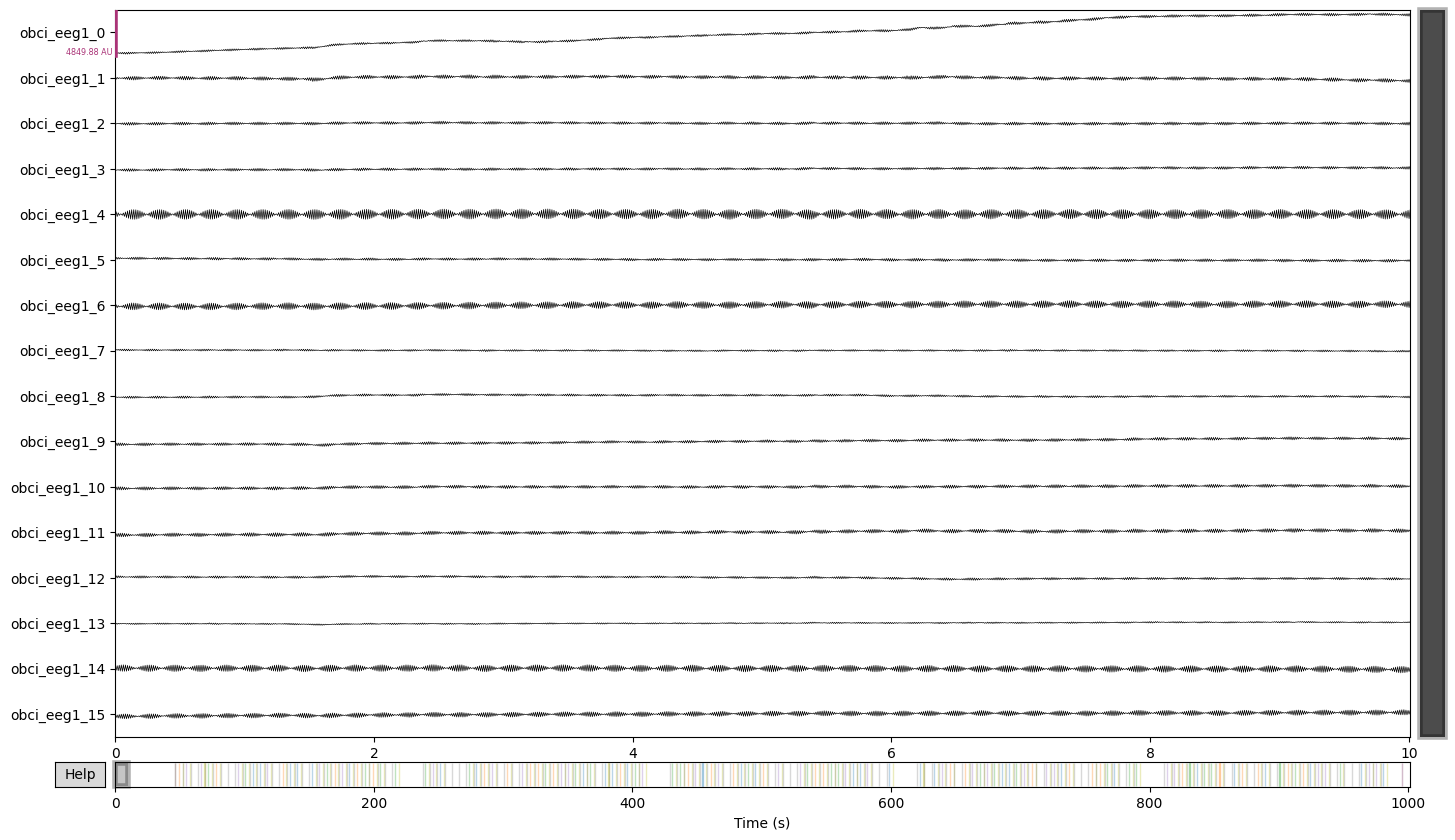

Channels marked as bad:
none


In [8]:
%matplotlib qt
raw_ori.plot()

In [4]:
raw_ori.set_channel_types({'obci_eeg1_0':'eeg','obci_eeg1_1':'eeg','obci_eeg1_2':'eeg','obci_eeg1_3':'eeg',
                       'obci_eeg1_4':'eeg','obci_eeg1_5':'eeg','obci_eeg1_6':'eeg','obci_eeg1_7':'eeg',
                       'obci_eeg1_8':'eeg','obci_eeg1_9':'eeg','obci_eeg1_10':'eeg','obci_eeg1_11':'eeg',
                       'obci_eeg1_12':'eeg','obci_eeg1_13':'eeg','obci_eeg1_14':'eeg','obci_eeg1_15':'eeg'
                     })
raw_ori.rename_channels({'obci_eeg1_0':'Fp1','obci_eeg1_1':'Fp2','obci_eeg1_2':'C3','obci_eeg1_3':'C4',
                     'obci_eeg1_4':'P7','obci_eeg1_5':'P8','obci_eeg1_6':'O1','obci_eeg1_7':'O2',
                     'obci_eeg1_8':'F7','obci_eeg1_9':'F8','obci_eeg1_10':'F3','obci_eeg1_11':'F4',
                     'obci_eeg1_12':'T7','obci_eeg1_13':'T8','obci_eeg1_14':'P3','obci_eeg1_15':'P4'
                     })
raw_ori.set_montage('standard_1020')

/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_64540/1818714966.py:1: RuntimeWarning: The unit for channel(s) obci_eeg1_0, obci_eeg1_1, obci_eeg1_10, obci_eeg1_11, obci_eeg1_12, obci_eeg1_13, obci_eeg1_14, obci_eeg1_15, obci_eeg1_2, obci_eeg1_3, obci_eeg1_4, obci_eeg1_5, obci_eeg1_6, obci_eeg1_7, obci_eeg1_8, obci_eeg1_9 has changed from NA to V.
  raw_ori.set_channel_types({'obci_eeg1_0':'eeg','obci_eeg1_1':'eeg','obci_eeg1_2':'eeg','obci_eeg1_3':'eeg',


<RawArray | sub-oreo_ses-1113_task-Default_run-001_eeg.xdf, 16 x 168751 (1350.0 s), ~20.6 MB, data loaded>

In [5]:
raw = raw_ori.copy()
raw.apply_function(lambda x: x * 1e-6 /10)

<RawArray | sub-oreo_ses-1113_task-Default_run-001_eeg.xdf, 16 x 168751 (1350.0 s), ~20.6 MB, data loaded>

Using matplotlib as 2D backend.


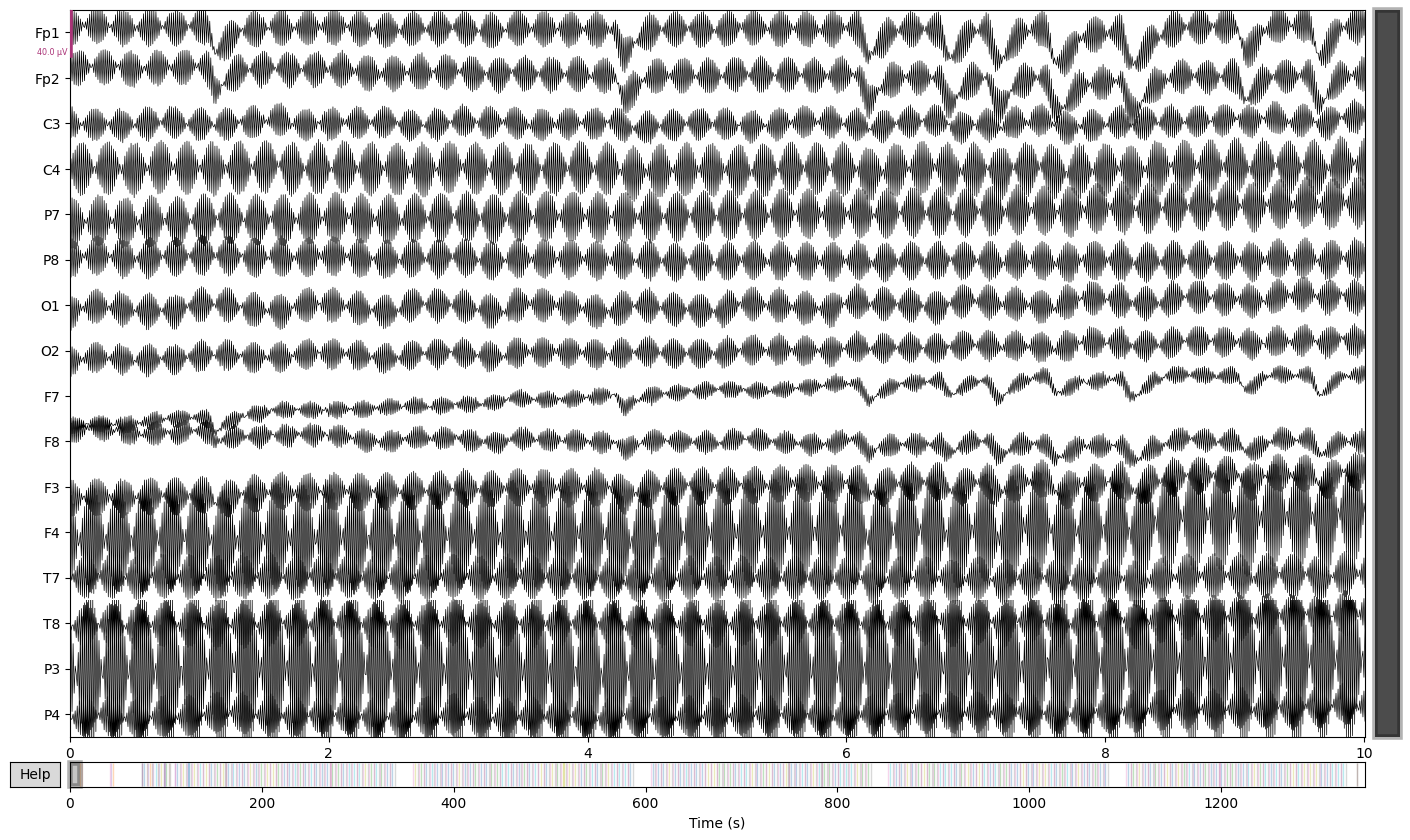

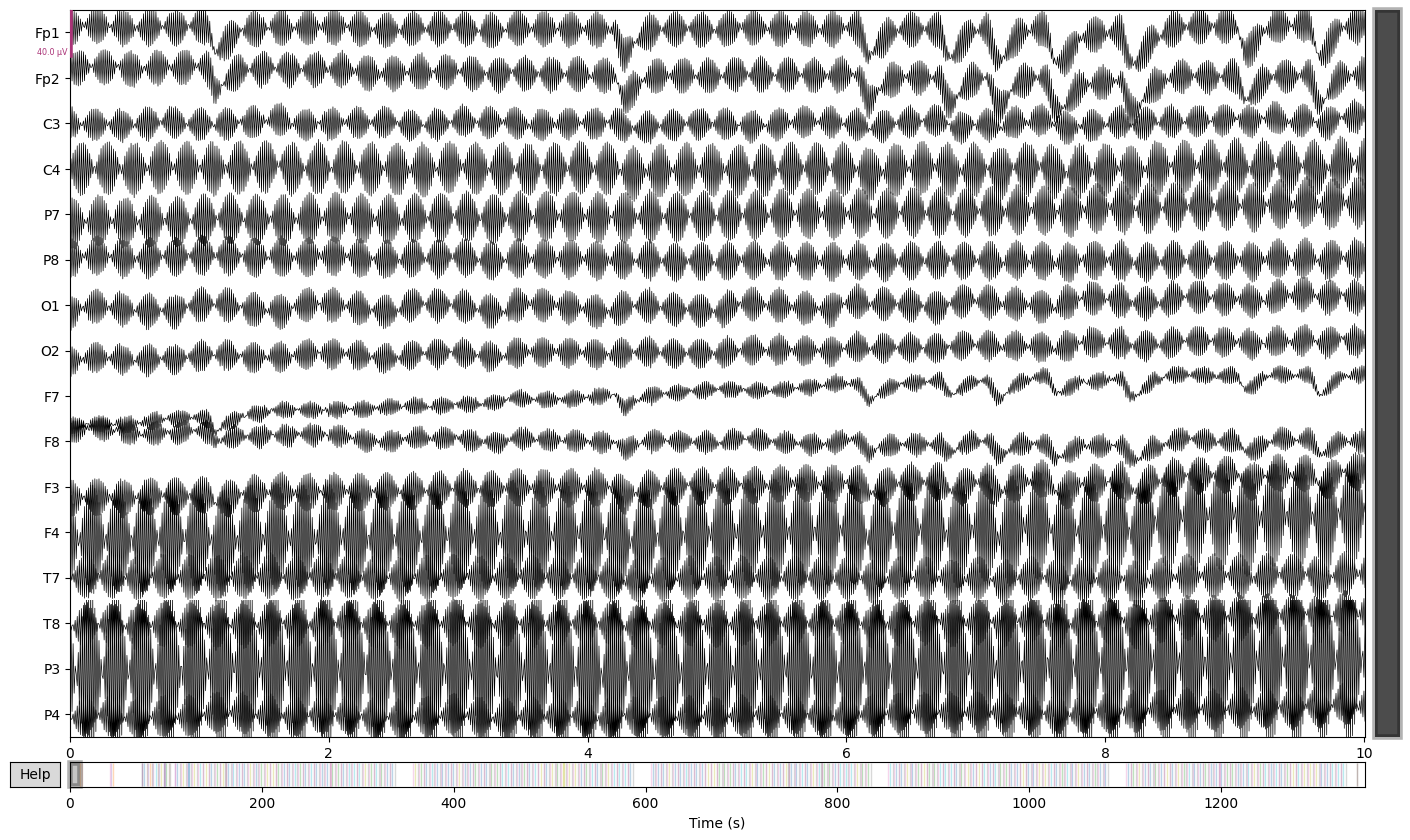

In [6]:
raw.plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 207 samples (1.656 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:    0.1s finished


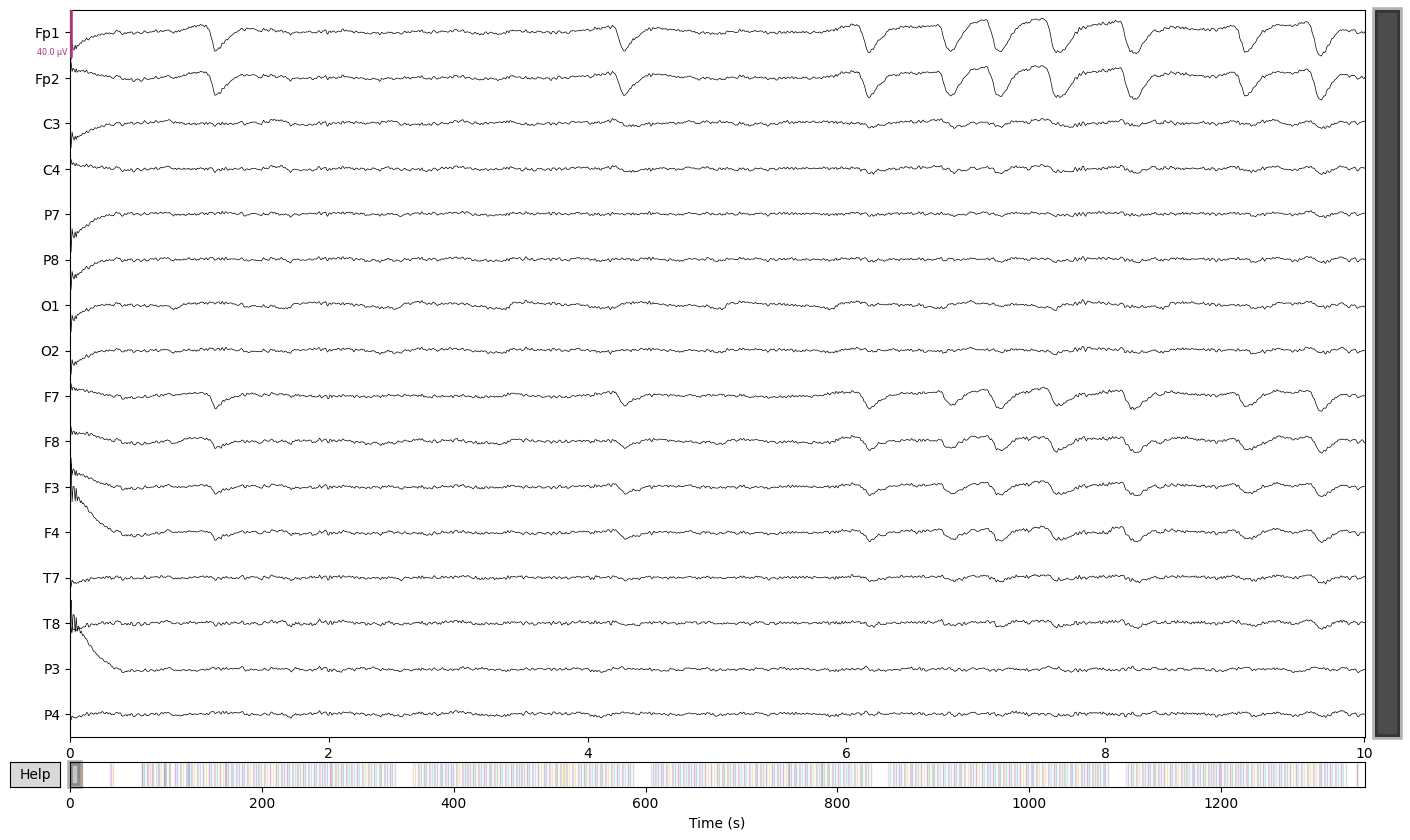

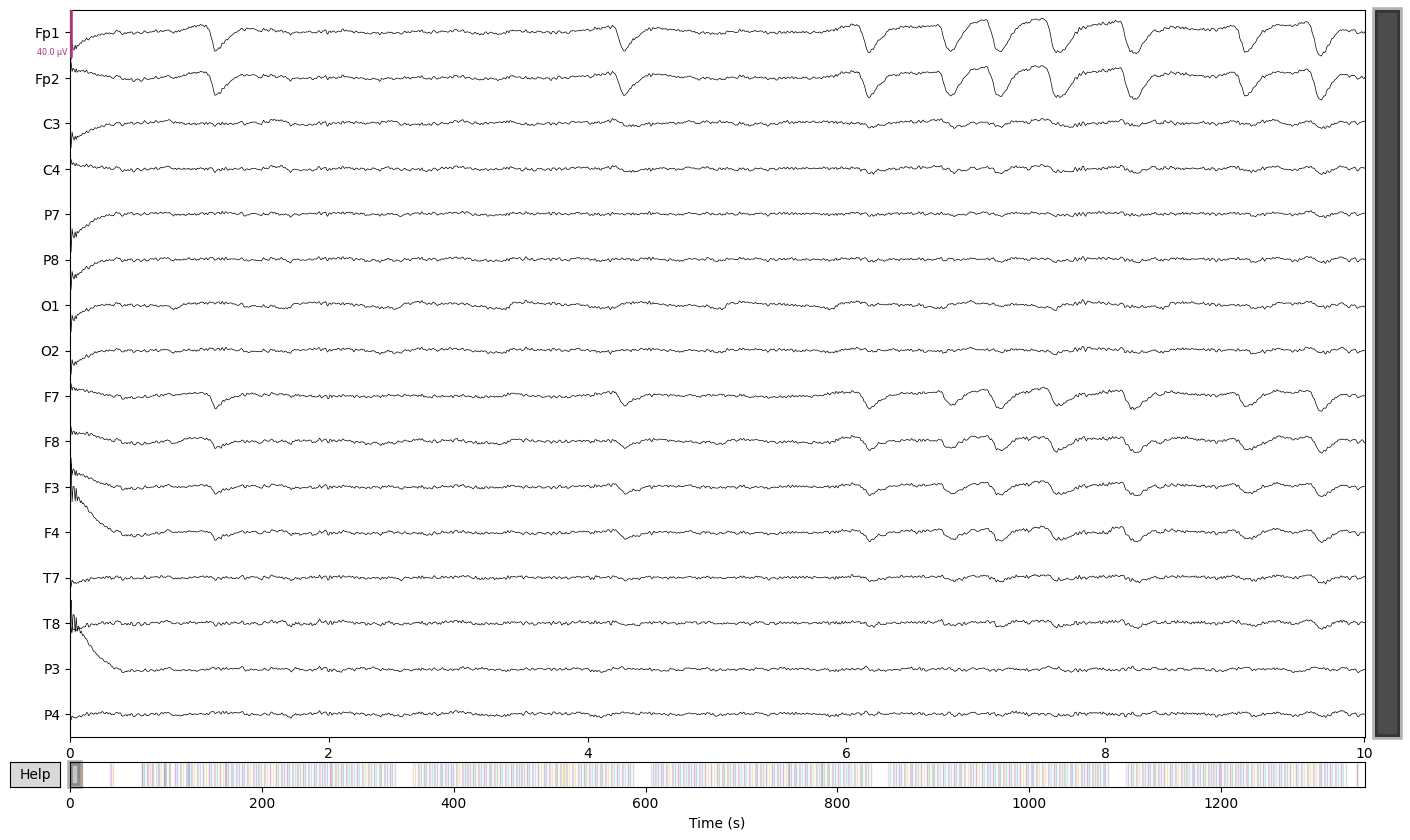

In [7]:
raw_filter = raw.copy().filter(l_freq=2, h_freq=45)
raw_filter.plot()

In [20]:
for ch in raw_filter.get_data():
    print(np.max(ch)-np.min(ch))

4.513612865765392e-05
4.1734809596019406e-05
7.728861007882506e-05
2.5241360320253585e-05
3.73330739893409e-05
2.074912319192084e-05
9.455225681522444e-05
0.00010466098634313953
7.763663614427838e-05
4.447505391128924e-05
4.7271128195039486e-05
2.6346729094763138e-05
2.916533215457451e-05
2.2135578481315788e-05
7.722010374560649e-05
2.932836476429953e-05


Effective window size : 2.048 (s)


/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


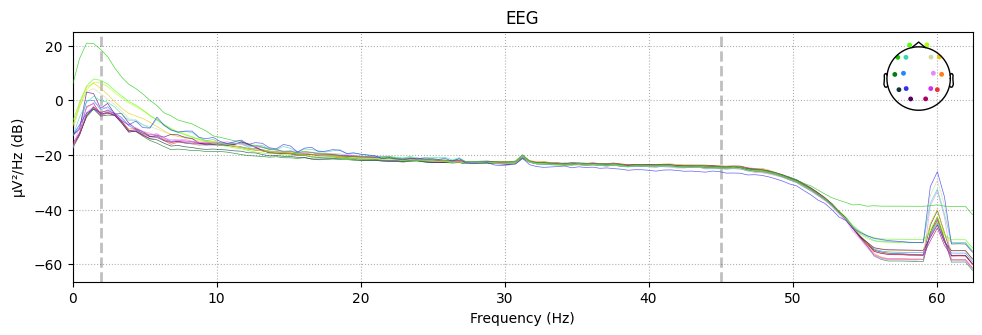

In [8]:
raw_filter.compute_psd().plot()

In [9]:
ica_filter = ICA(
    n_components=13,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica_filter.fit(raw_filter)

ic_labels_filter = label_components(raw_filter, ica_filter, method="iclabel")

print(ic_labels_filter["labels"])

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 13 components
Computing Extended Infomax ICA
Fitting ICA took 21.7s.


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_64540/3824300734.py:10: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_filter = label_components(raw_filter, ica_filter, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_64540/3824300734.py:10: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_filter = label_components(raw_filter, ica_filter, method="iclabel")


['other', 'eye blink', 'brain', 'line noise', 'brain', 'line noise', 'line noise', 'brain', 'eye blink', 'brain', 'line noise', 'brain', 'line noise']


In [11]:
events,all_events_id=mne.events_from_annotations(raw,event_id='auto')

Used Annotations descriptions: ['BH', 'EOG-close begin', 'EOG-close end', 'EOG-close trial', 'EOG-open begin', 'EOG-open end', 'EOG-open trial', 'F', 'LH', 'RH', 'SESSION-begin', 'SSVEP', 'Warm-up trial-begin', 'Warm-up trial-end', 'Warm-up-begin', 'Warm-up-end', 'Warm-upBH', 'Warm-upF', 'Warm-upLH', 'Warm-upRH', 'Warm-upSSVEP', 'calib-begin', 'calib-end', 'trial-begin', 'trial-end']


In [12]:
all_events_id

{'BH': 1,
 'EOG-close begin': 2,
 'EOG-close end': 3,
 'EOG-close trial': 4,
 'EOG-open begin': 5,
 'EOG-open end': 6,
 'EOG-open trial': 7,
 'F': 8,
 'LH': 9,
 'RH': 10,
 'SESSION-begin': 11,
 'SSVEP': 12,
 'Warm-up trial-begin': 13,
 'Warm-up trial-end': 14,
 'Warm-up-begin': 15,
 'Warm-up-end': 16,
 'Warm-upBH': 17,
 'Warm-upF': 18,
 'Warm-upLH': 19,
 'Warm-upRH': 20,
 'Warm-upSSVEP': 21,
 'calib-begin': 22,
 'calib-end': 23,
 'trial-begin': 24,
 'trial-end': 25}

In [13]:
events[:100]

array([[ 1288,     0,    11],
       [ 1288,     0,     7],
       [ 1525,     0,     5],
       [ 5275,     0,     6],
       [ 5357,     0,     4],
       [ 5590,     0,     2],
       [ 9340,     0,     3],
       [ 9422,     0,    15],
       [ 9422,     0,    13],
       [ 9669,     0,    19],
       [10044,     0,    14],
       [10126,     0,    13],
       [10373,     0,    20],
       [10748,     0,    14],
       [10831,     0,    13],
       [11154,     0,    18],
       [11529,     0,    14],
       [11610,     0,    13],
       [11857,     0,    17],
       [12232,     0,    14],
       [12314,     0,    13],
       [12546,     0,    21],
       [12935,     0,    14],
       [13018,     0,    16],
       [13712,     0,    22],
       [13712,     0,    24],
       [13959,     0,     1],
       [14334,     0,    25],
       [14416,     0,    24],
       [14738,     0,     8],
       [15113,     0,    25],
       [15194,     0,    24],
       [15441,     0,     1],
       [15

In [14]:
all_events_id

{'BH': 1,
 'EOG-close begin': 2,
 'EOG-close end': 3,
 'EOG-close trial': 4,
 'EOG-open begin': 5,
 'EOG-open end': 6,
 'EOG-open trial': 7,
 'F': 8,
 'LH': 9,
 'RH': 10,
 'SESSION-begin': 11,
 'SSVEP': 12,
 'Warm-up trial-begin': 13,
 'Warm-up trial-end': 14,
 'Warm-up-begin': 15,
 'Warm-up-end': 16,
 'Warm-upBH': 17,
 'Warm-upF': 18,
 'Warm-upLH': 19,
 'Warm-upRH': 20,
 'Warm-upSSVEP': 21,
 'calib-begin': 22,
 'calib-end': 23,
 'trial-begin': 24,
 'trial-end': 25}

In [17]:
#write offline epoch
event_id = dict({'LH': 9,'RH': 10, 'F': 8, 'BH': 1})
tmin = -1
tmax = 3
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, baseline=(-0.5,0) , preload=True, event_repeated = 'drop')

Not setting metadata
160 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 160 events and 501 original time points ...
0 bad epochs dropped


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/mne/viz/utils.py:137: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  (fig or plt).show(**kwargs)


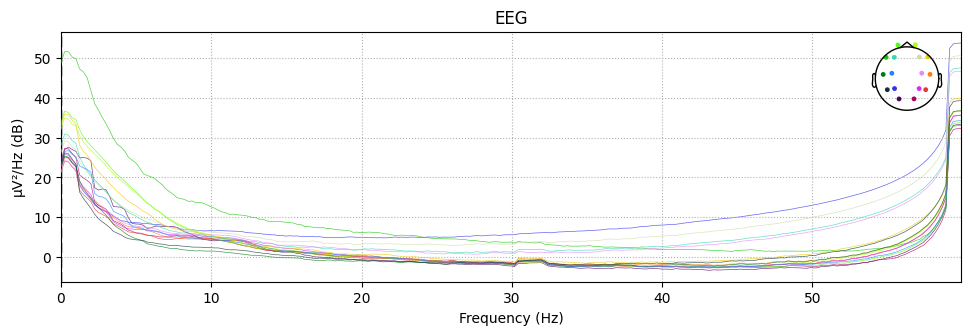

In [18]:
epochs.plot_psd(fmax=60)

In [ ]:
raw_clean = raw.copy()

ica_clean = ICA(
    n_components=16,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica_clean.fit(raw_clean)

ic_labels_clean = label_components(raw_clean, ica_clean, method="iclabel")

print(ic_labels_clean["labels"])

In [ ]:
ica_filter = ICA(
    n_components=16,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica_filter.fit(raw_filter)

ic_labels_filter = label_components(raw_filter, ica_filter, method="iclabel")

print(ic_labels_filter["labels"])

In [ ]:
raw_asr = raw.copy().filter(l_freq=1, h_freq=50,method='fir')
#raw_asr = raw_asr.set_eeg_reference("REST")

# Apply the ASR
asr = ASR(sfreq=raw_asr.info["sfreq"], cutoff=15)
asr.fit(raw_asr)
raw_asr = asr.transform(raw_asr)

ica_asr = ICA(
    n_components=16,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica_asr.fit(raw_asr)

ic_labels_asr = label_components(raw_asr, ica_asr, method="iclabel")

print(ic_labels_asr["labels"])

In [32]:
raw_asr = raw.copy().filter(l_freq=1, h_freq=45)
#raw_asr = raw_asr.set_eeg_reference(ref_channels='average')

# Apply the ASR
asr = ASR(sfreq=raw_asr.info["sfreq"], cutoff=20)
asr.fit(raw_asr)
raw_asr = asr.transform(raw_asr)

ica_asr = ICA(
    n_components=13,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)
ica_asr.fit(raw_asr)

ic_labels_asr = label_components(raw_asr, ica_asr, method="iclabel")

print(ic_labels_asr["labels"])

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 413 samples (3.304 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  16 out of  16 | elapsed:    0.1s finished


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 13 components
Computing Extended Infomax ICA
Fitting ICA took 13.1s.


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_83692/531030538.py:18: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_asr = label_components(raw_asr, ica_asr, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_83692/531030538.py:18: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_asr = label_components(raw_asr, ica_asr, method="iclabel")


['eye blink', 'brain', 'other', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'other', 'brain', 'brain', 'eye blink']


Effective window size : 2.048 (s)


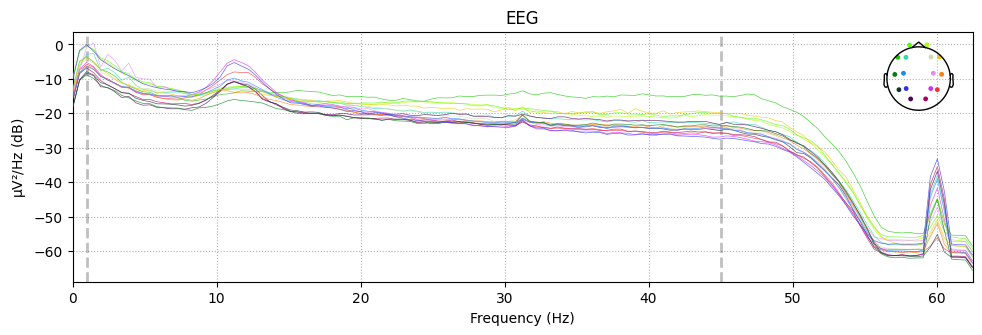

In [25]:
raw_asr.compute_psd().plot()

In [41]:
#write offline epoch
event_id = dict({'LH': 2,'RH': 3, 'F': 1, 'T': 4})
tmin = -1
tmax = 3
epochs = mne.Epochs(raw_asr, events, event_id, tmin, tmax, baseline=(-1,0) , preload=True, event_repeated = 'drop')

Not setting metadata
120 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 120 events and 501 original time points ...
0 bad epochs dropped


In [42]:
epochs.events[:, -1]

array([2, 3, 1, 4, 2, 2, 4, 3, 3, 4, 1, 1, 3, 4, 4, 4, 2, 2, 3, 3, 3, 3,
       3, 2, 3, 3, 1, 1, 2, 1, 1, 3, 1, 2, 2, 1, 4, 1, 3, 2, 1, 4, 2, 4,
       2, 4, 3, 3, 4, 2, 1, 1, 1, 3, 3, 3, 1, 2, 3, 4, 4, 1, 3, 2, 3, 4,
       3, 2, 2, 1, 2, 4, 4, 3, 3, 4, 1, 4, 1, 3, 2, 3, 2, 4, 2, 2, 3, 1,
       1, 1, 4, 4, 1, 4, 2, 1, 1, 2, 1, 2, 2, 1, 3, 3, 1, 4, 2, 4, 4, 2,
       4, 2, 2, 1, 1, 4, 3, 4, 4, 4])

In [22]:
from pyriemann.estimation import Covariances, ERPCovariances, XdawnCovariances
from pyriemann.spatialfilters import CSP
from pyriemann.tangentspace import TangentSpace
from pyriemann.classification import MDM
from collections import OrderedDict
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedShuffleSplit
import pandas as pd
import seaborn as sns

CSP + RegLDA
Cov + TS
Cov + MDM
CSP + Cov + TS


<Figure size 640x480 with 0 Axes>

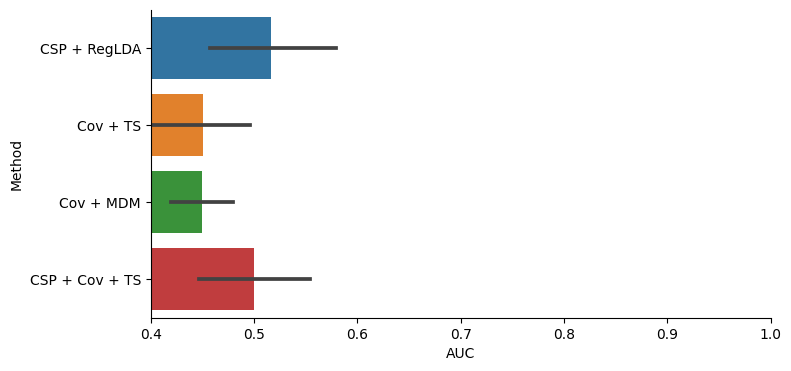

In [23]:
%matplotlib inline



X = epochs.get_data() * 1e6
times = epochs.times
y = epochs.events[:, -1]

# - CSP + RegLDA : Common Spatial Patterns + Regularized Linear Discriminat Analysis. 
##This is a very common EEG analysis pipeline.
# - Cov + TS : Covariance + Tangent space mapping. 
##One of the most reliable Riemannian geometry-based pipelines.
# - Cov + MDM: Covariance + MDM. 
##A very simple, yet effective (for low channel count), Riemannian geometry classifier.
# - CSP + Cov + TS: Common Spatial Patterns + Covariance + Tangent spacem mapping. 
##Riemannian pipeline with the standard CSP procedure beforehand

clfs = OrderedDict()
clfs['CSP + RegLDA'] = make_pipeline(Covariances(), CSP(4), 
                                     LinearDiscriminantAnalysis(shrinkage='auto', solver='eigen'))
clfs['Cov + TS'] = make_pipeline(Covariances(), TangentSpace(), LogisticRegression())
clfs['Cov + MDM'] = make_pipeline(Covariances(), MDM())
clfs['CSP + Cov + TS'] = make_pipeline(Covariances(), CSP(4, log=False), 
                                       TangentSpace(), LogisticRegression())

# define cross validation
cv = StratifiedShuffleSplit(n_splits=20, test_size=0.25,
                                        random_state=42)

# run cross validation for each pipeline
auc = []
methods = []
for m in clfs:
    print(m)
    try:
        res = cross_val_score(clfs[m], X, y==4, scoring='roc_auc',cv=cv, n_jobs=-1)
        auc.extend(res)
        methods.extend([m]*len(res))
    except:
        pass

results = pd.DataFrame(data=auc, columns=['AUC'])
results['Method'] = methods
plt.clf()
fig = plt.figure(figsize=[8,4])
sns.barplot(data=results, x='AUC', y='Method')
plt.xlim(0.4, 1)
sns.despine()
plt.show()

In [11]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

'''
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LeakyReLU, Dense, Bidirectional, Activation, Flatten, Dropout
from keras.layers import Conv2DTranspose, Conv2D, LSTM, BatchNormalization, MaxPooling2D, Reshape
from keras.utils import to_categorical
from keras.regularizers import L1L2
from keras.initializers import lecun_uniform
from keras.optimizers import Adam
from keras.metrics import categorical_accuracy
'''


from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedShuffleSplit,ShuffleSplit, cross_val_score, train_test_split

import mne
from mne import Epochs, pick_types
from mne.decoding import CSP

warnings.filterwarnings("ignore")

In [1]:
binary_class_dict

NameError: name 'binary_class_dict' is not defined

In [2]:
event_name = ["LH", "RH", "F", "BH"]

# set binary class combination
binary_class_dict = {}
id = 0
for i, name in enumerate(event_name):
  for j in range(i+1,len(event_name)):
    binary_class_dict[id] = (event_name[i], event_name[j])
    id += 1
del id
'''
output
binary_class_dict =  {0: ('LH', 'RH'),
                      1: ('LH', 'F'),
                      2: ('LH', 'T'),
                      3: ('RH', 'F'),
                      4: ('RH', 'T'),
                      5: ('F', 'T')}
'''

band_default = (6, 30)  # Hz
band_dict = {}
for binary_class in binary_class_dict.values():
  band_dict[binary_class] = band_default    

In [32]:
band_dict

{('LH', 'RH'): (6, 30),
 ('LH', 'F'): (6, 30),
 ('LH', 'BH'): (6, 30),
 ('RH', 'F'): (6, 30),
 ('RH', 'BH'): (6, 30),
 ('F', 'BH'): (6, 30)}

In [12]:
#write event and make stim channel
events,all_events_id=mne.events_from_annotations(raw_filter,event_id='auto')

Used Annotations descriptions: ['BH', 'F', 'LH', 'RH', 'calib-begin', 'calib-end', 'trial-begin', 'trial-end']


In [14]:
event_dict = {'BH': 1,
 'F': 2,
 'LH': 3,
 'RH': 4}

In [15]:
picks = pick_types(raw.info, eeg=True, stim=False, eog=False, exclude="bads")

epochs = mne.Epochs(
    raw_filter,
    events,
    event_id = event_dict,
    tmin = 0,
    tmax = 3,
    picks = picks,
    baseline = None,
    reject = None,
    preload = True,
)

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 376 original time points ...
0 bad epochs dropped


In [16]:
def csp_svm(class1, class2, Bl, Bh, random_state):
  scores = []
  epochs_filtered = epochs.copy()[class1,class2].crop(tmin=1, tmax=3).filter(Bl, Bh, method='iir',verbose = False)
  epochs_data = epochs_filtered.copy().get_data()
  labels = epochs[class1, class2].events[:, -1]
  cv = StratifiedShuffleSplit(30, test_size=0.3,random_state=random_state)

  # Assemble a classifier
  svm = SVC()
  csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)

  # Use scikit-learn Pipeline with cross_val_score function
  clf = Pipeline([("CSP", csp), ("SVC", svm)])
  scores = cross_val_score(clf, epochs_data, labels, cv=cv, n_jobs=-1)

  # Printing the results
  accuracy = np.mean(scores)
  print(f"Bl {Bl} | Bh {Bh} | Classification accuracy: {accuracy}")
  return accuracy

In [17]:
def bestBand_selected(class1, class2):
  print(f"Start selecting combination {class1}/{class2}...")
  Bl = band_dict[(class1,class2)][0]
  Bh = band_dict[(class1,class2)][1]
  random_state = 0
  A1 = 0
  A2 = 0
  result = {}

  #adjust Bl
  """
  #Bl try downward
  while A1 >= A2 and Bl >= 0:
    A2 = A1
    if (Bl-2,Bh) not in result:
      result[(Bl-2,Bh)] = csp_svm(class1, class2, Bl-2, Bh, random_state)
    A1 = result[(Bl-2,Bh)]
    if A1 >= A2:
      Bl = Bl - 2
  """
  result[(Bl,Bh)] = csp_svm(class1, class2, Bl, Bh, random_state)
  A1 = result[(Bl,Bh)]
  #Bl try upward
  while A1 >= A2 and Bl <= Bh-6:
    A2 = A1
    if (Bl+2,Bh) not in result:
      result[(Bl+2,Bh)] = csp_svm(class1, class2, Bl+2, Bh, random_state)
    A1 = result[(Bl+2,Bh)]
    if A1 >= A2:
      Bl = Bl + 2
  print(f"--------------------- Final Bl = {Bl} ---------------------")

  #adjust Bh
  #Bh try downward
  A1 = A2
  while A1 >= A2 and Bh >= Bl+6:
    A2 = A1
    if (Bl,Bh-2) not in result:
      result[(Bl,Bh-2)] = csp_svm(class1, class2, Bl, Bh-2, random_state)
    A1 = result[(Bl,Bh-2)]
    if A1 >= A2:
      Bh = Bh - 2
  #Bl try upward
  A1 = A2
  while A1 >= A2 and Bh <= 38:
    A2 = A1
    if (Bl,Bh+2) not in result:
      result[(Bl,Bh+2)] = csp_svm(class1, class2, Bl, Bh+2, random_state)
    A1 = result[(Bl,Bh+2)]
    if A1 >= A2:
      Bh = Bh + 2
  print(f"--------------------- Final Bh = {Bh} ---------------------")
  print(f"Combination {class1}/{class2} Finised| {Bl} - {Bh} ")
  return (Bl, Bh)

In [18]:
for i,binary_class in binary_class_dict.items():
  class1, class2 = binary_class
  band_dict[binary_class] = bestBand_selected(class1, class2)

Start selecting combination LH/RH...


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/sklearn/pipeline.py", line 401, in fit
    Xt = self._fit(X, y, **fit_params_steps)
  File "/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/sklearn/pipeline.py", line 359, in _fit
    X, fitted_transformer = fit_transform_one_cached(
  File "/Users/alkalisk/miniforge3/envs/BCI_env/lib/python3.8/site-packages/joblib/memory.py", line 349, in __call__
    r